<a href="https://colab.research.google.com/github/Jeshurun-B/EMA-optimizer-pipeline-v2/blob/main/coolab_notebooks/week2_logistic_regression%20v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📅 Week 2 — Logistic Regression Deep Dive
**EMA Crossover ML Project | 10-Week Curriculum**
**Date:** June 8, 2026

---

### What This Week Is About
Week 1 proved that linear regression can't reliably predict signal quality on this data — assumption violations were widespread, and performance ranged from decent (BTC/ETH with Target 3, short side) to near-zero (global LONG with the hard-gate Control target). This week you pivot to **binary classification**: instead of predicting a continuous quality score, you predict whether a signal is *good enough to trade* (1) or not (0). You will define three candidate binary targets, choose the one most aligned with your trading goals, and build a full Logistic Regression pipeline covering the mathematics, probability output, confusion matrix, regularisation, and threshold tuning. This is the model every more powerful algorithm (trees, boosting, neural nets) will be benchmarked against.

**By end of week you will have:**
- A justified binary target with documented class balance
- Trained Logistic Regression baselines for both LONG and SHORT
- Confusion matrix, ROC curve, and Precision-Recall curve interpreted in trading terms
- A regularisation sweep (C = [0.01, 0.1, 1, 10, 100]) with a chosen operating threshold
- Odds ratios for the top features explaining *why* the model flags a signal as good


## Section 0 — Environment Setup

Run this first every session.

In [ ]:
# Install required libraries
!pip install -q supabase scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 2.9 MB/s eta 0:00:00


In [ ]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from supabase import create_client
from google.colab import userdata

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Environment ready')


Environment ready


## Section 1 — Connect to Both Databases

Same dual-connection pattern from Week 1. Run every session.

In [ ]:
# ============================================================
# CONNECT TO MAIN DATABASE
# ============================================================
try:
    main_client = create_client(userdata.get('SUPABASE_URL'), userdata.get('SUPABASE_KEY'))
    print('Main database connected')
except Exception as e:
    print(f'Main connection failed: {e}')


Main database connected


In [ ]:
# ============================================================
# CONNECT TO ANALYTICS DATABASE
# ============================================================
try:
    analytics_client = create_client(
        userdata.get('ANALYTICS_SUPABASE_URL'),
        userdata.get('ANALYTICS_SUPABASE_KEY')
    )
    print('Analytics database connected')
except Exception as e:
    print(f'Analytics connection failed: {e}')


Analytics database connected


## Section 2 — Fetch Data and Merge

Fetch both tables, parse datetime columns with `utc=True`, inner-join on `(symbol, checked_at_utc)`. Identical to Week 1.

In [ ]:
# ============================================================
# FETCH: Main signals table
# ============================================================
response_main = main_client.table('signals').select('*').eq('status', 'analyzed').execute()
df_main = pd.DataFrame(response_main.data)

for col in ['checked_at_utc', 'time_of_max_price', 'time_of_min_price']:
    if col in df_main.columns:
        df_main[col] = pd.to_datetime(df_main[col], utc=True, errors='coerce')

df_main = df_main.sort_values('checked_at_utc').reset_index(drop=True)
print(f'Main signals: {len(df_main):,} rows | {df_main.shape[1]} columns')
print(f'Range: {df_main["checked_at_utc"].min().date()} to {df_main["checked_at_utc"].max().date()}')
print(f'Signal split: {df_main["signal"].value_counts().to_dict()}')


Main signals: 6,773 rows | 48 columns
Range: 2025-10-03 to 2026-06-14
Signal split: {'SHORT': 3388, 'LONG': 3385}


In [ ]:
# ============================================================
# FETCH: Analytics table
# ============================================================
response_analytics = analytics_client.table('crossover_analytics').select('*').execute()
df_analytics = pd.DataFrame(response_analytics.data)

for col in ['crossover_utc', 'next_crossover_utc', 'optimal_entry_utc']:
    if col in df_analytics.columns:
        df_analytics[col] = pd.to_datetime(df_analytics[col], utc=True, errors='coerce')

df_analytics = df_analytics.sort_values('crossover_utc').reset_index(drop=True)
print(f'Analytics: {len(df_analytics):,} rows | {df_analytics.shape[1]} columns')


Analytics: 7,376 rows | 14 columns


In [ ]:
# ============================================================
# MERGE: inner join on (symbol, checked_at_utc)
# ============================================================
df_analytics_renamed = df_analytics.rename(columns={'crossover_utc': 'checked_at_utc'})
df = pd.merge(df_main, df_analytics_renamed, how='inner', on=['checked_at_utc', 'symbol'])

main_lost      = len(df_main) - len(df)
analytics_lost = len(df_analytics) - len(df)

print(f'Merged dataset: {len(df):,} rows | {df.shape[1]} columns')
print(f'Lost from main (no analytics match): {main_lost:,} ({main_lost/len(df_main)*100:.1f}%)')
print(f'Lost from analytics (no main match): {analytics_lost:,}')
print()
print('Records per symbol:')
print(df['symbol'].value_counts())


Merged dataset: 6,773 rows | 60 columns
Lost from main (no analytics match): 0 (0.0%)
Lost from analytics (no main match): 603

Records per symbol:
symbol
ETHUSDT     1404
SOLUSDT     1366
BTCUSDT     1344
XRPUSDT     1340
DOGEUSDT    1319
Name: count, dtype: int64


## Section 3 — Apply Signal Quality Columns

Your **evolved 4-track target system** from Week 1. Applied every week after merge.

| Column | Range | Role this week |
|--------|-------|----------------|
| `T1_Pure_Continuous` | 0–10 | Smooth linear R:R + time decay. No hard gates. |
| `T2_Soft_Floor` | 0–10 | Sub-0.25% risk trades penalised 90%, not zeroed. |
| `T3_Assumption_Penalty` | 0–10 | Subtractive penalties for volume, HTF trend, adverse excursion. |
| `T4_Control_Punished` | 0–10 | Original hard-gate baseline (the lazy model trap). |
| `target_special` | 0–10 | **Production target.** Row-wise min of T1–T3. |
| `Optimum_entry` | float | **Candle-based timing.** 15-min candles from crossover to optimal entry. |

> `Optimum_entry` was refactored in Week 1 from a categorical (1–6) to a **continuous candle count** (time delta between `optimal_entry_utc` and `checked_at_utc` divided by 15 minutes). This more precisely reflects real entry timing structure.


In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# SIGNAL QUALITY SCORING MODULE (Week 1 final version)
# ============================================================

def get_time_decay_score(candles):
    if candles <= 20:
        return 1.0
    elif candles <= 100:
        t = (candles - 20) / 80
        return np.exp(-3.5 * t)
    elif candles <= 400:
        base = np.exp(-3.5)
        t = (candles - 100) / 300
        return base * np.exp(-4 * t)
    else:
        return 0.0

def time_cutoff(candles):
    if candles <= 20:   return 1.0
    elif candles <= 40: return 0.5
    else:               return 0

def calculate_four_target_scores(row):
    is_long = str(row['signal_x']).upper() == 'LONG'
    if is_long:
        p, r = float(row['max_move_up_pct']), float(row['max_move_down_pct'])
        candles_to_peak_profit = int(row['candles_to_max_price'])
        candles_to_max_pain    = int(row['candles_to_min_price'])
        is_btc  = bool(row['btc_trend_bias'])
        is_1d   = bool(row['htf_1d_bias'])
        is_4h   = bool(row['htf_4h_bias'])
    else:
        p, r = float(row['max_move_down_pct']), float(row['max_move_up_pct'])
        candles_to_peak_profit = int(row['candles_to_min_price'])
        candles_to_max_pain    = int(row['candles_to_max_price'])
        is_btc  = not bool(row['btc_trend_bias'])
        is_1d   = not bool(row['htf_1d_bias'])
        is_4h   = not bool(row['htf_4h_bias'])

    r_safe = 0.01 if r <= 0 else r
    current_rr  = p / r_safe
    t_factor    = get_time_decay_score(candles_to_peak_profit)
    base        = round(min(5.0, current_rr) + 5.0 * t_factor, 2)

    t1 = base

    if candles_to_max_pain < candles_to_peak_profit and r >= p:
        t2 = round(base * 0.2, 2)
    elif r < 0.25:
        t2 = round(base * 0.1, 2)
    else:
        t2 = base

    pen = base
    if 'volume_ratio' in row and float(row['volume_ratio']) < 1.0: pen -= 0.8
    if not is_btc:  pen -= 0.5
    if not is_1d:   pen -= 1.0
    if not is_4h:   pen -= 1.2
    if candles_to_max_pain < candles_to_peak_profit and r > 0.75 * p: pen -= 0.8
    t3 = round(max(0, pen), 2)

    if r < 0.25 or (candles_to_max_pain < candles_to_peak_profit and r >= p):
        t4 = 0.0
    else:
        if current_rr >= 4:              rr_p = 5.0
        elif current_rr >= 1.5:          rr_p = current_rr
        elif 1.0 <= current_rr < 1.5:   rr_p = (current_rr**7) / (1.5**6)
        else:                             rr_p = 0.0
        t_s = time_cutoff(candles_to_peak_profit)
        t4  = round(5.0 * t_s + rr_p, 2) if rr_p > 0 else 0.0

    return t1, t2, t3, t4


def optimal_entry_candles(row):
    """Returns 15-min candles from crossover to optimal entry. 0 = immediate entry."""
    try:
        if pd.isnull(row['optimal_entry_utc']) or pd.isnull(row['checked_at_utc']):
            return 0.0
        diff = row['optimal_entry_utc'] - row['checked_at_utc']
        return float(diff.total_seconds() / 60 / 15)
    except Exception:
        return 0.0


# Apply
target_cols = ['T1_Pure_Continuous', 'T2_Soft_Floor', 'T3_Assumption_Penalty', 'T4_Control_Punished']
df[target_cols] = df.apply(lambda r: pd.Series(calculate_four_target_scores(r)), axis=1)
df['target_special'] = df[target_cols[:3]].min(axis=1)
df['Optimum_entry']  = df.apply(optimal_entry_candles, axis=1)

print('All quality columns applied.')
print('\n--- % scoring above 5.0 ---')
for col in target_cols + ['target_special']:
    print(f'  {col:<28} -> {(df[col] > 5).mean()*100:.1f}%')
print(f'\n  Optimum_entry median: {df["Optimum_entry"].median():.1f} candles | mean: {df["Optimum_entry"].mean():.1f}')


All quality columns applied.

--- % scoring above 5.0 ---
  T1_Pure_Continuous           -> 98.5%
  T2_Soft_Floor                -> 78.1%
  T3_Assumption_Penalty        -> 36.6%
  T4_Control_Punished          -> 28.6%
  target_special               -> 26.8%

  Optimum_entry median: 0.0 candles | mean: 1.0


In [ ]:
df[['checked_at_utc','symbol','signal_x', 'max_move_up_pct' , 'max_move_down_pct' , 'mfe_percent' , 'mae_percent','optimal_entry', 'optimal_entry_utc']].tail(20)

,checked_at_utc,symbol,signal_x,max_move_up_pct,max_move_down_pct,mfe_percent,mae_percent,optimal_entry,optimal_entry_utc
6753,2026-06-13 17:00:00+00:00,BTCUSDT,SHORT,0.4972,0.0315,0.03,-0.21,64098.00000,2026-06-13 17:15:00+00:00
6754,2026-06-13 18:30:00+00:00,BTCUSDT,LONG,0.7734,0.3288,0.77,-0.33,64054.48000,2026-06-13 18:45:00+00:00
6755,2026-06-13 18:30:00+00:00,ETHUSDT,LONG,0.0321,0.3704,0.03,-0.14,1679.78000,2026-06-13 18:30:00+00:00
6756,2026-06-13 20:15:00+00:00,ETHUSDT,SHORT,1.2540,0.0805,0.08,-0.12,1678.22000,2026-06-13 20:15:00+00:00
6757,2026-06-13 21:30:00+00:00,XRPUSDT,LONG,0.2513,0.7193,0.25,-0.72,1.14560,2026-06-13 21:30:00+00:00
6758,2026-06-13 21:30:00+00:00,ETHUSDT,LONG,0.5635,0.6737,0.56,-0.67,1676.40000,2026-06-13 21:30:00+00:00
6759,2026-06-13 21:30:00+00:00,DOGEUSDT,LONG,0.2944,0.7132,0.29,-0.71,0.08770,2026-06-13 21:30:00+00:00
6760,2026-06-14 00:15:00+00:00,DOGEUSDT,SHORT,0.3532,0.2279,0.23,-0.19,0.08794,2026-06-14 00:15:00+00:00
6761,2026-06-14 02:00:00+00:00,DOGEUSDT,LONG,0.1704,0.6022,0.17,-0.28,0.08776,2026-06-14 02:00:00+00:00
6762,2026-06-14 03:30:00+00:00,ETHUSDT,SHORT,0.1756,1.4976,1.50,-0.18,1683.01000,2026-06-14 03:30:00+00:00


## Section 4 — Feature Sets

Your Week 1 MI analysis produced two separate 15-feature matrices. These are your inputs for all models this week.


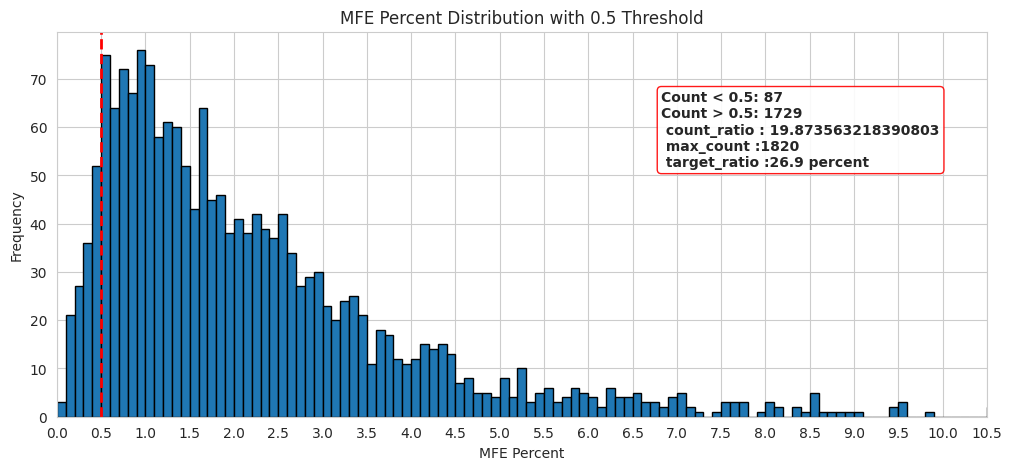

In [ ]:
# list = []
# for i in range (0,10):
#     dd = df[(df['T3_Assumption_Penalty'] > i ) & (df['mfe_percent'] >0.3)]['T3_Assumption_Penalty']
#     lenght = len(dd)
#     list.append(lenght)
# plt.plot(range(0,10),list)



# 1. Filter the data (ensuring we don't pre-filter out values <= 0.5 so we can count them!)
filtered_data = df[(df['T3_Assumption_Penalty'] > 5.5)]['mfe_percent']

# 2. Calculate the exact counts relative to the 0.5 threshold
max_count =  (df['T3_Assumption_Penalty'] > 5.5).sum()
count_below_05 = (filtered_data < 0.4).sum()
count_above_05 = (filtered_data > 0.4).sum()
count_ratio = (count_above_05/count_below_05)
target_ratio = f'{round((max_count / (df['T3_Assumption_Penalty'] > 0).sum())*100 , 2)} percent'

# 3. BINS: High-resolution 0.1 intervals from 0 to 20
bin_edges = np.arange(0, 20.11, 0.1)

# 4. Plot the histogram
plt.hist(filtered_data, bins=bin_edges, edgecolor='black')

# 5. Add a prominent red vertical line at x = 0.5
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold (0.5)')

# 6. Display the counts inside a clean text box in the upper right
# Using transform=plt.gca().transAxes keeps the box in place regardless of data scale
text_info = f'Count < 0.5: {count_below_05}\nCount > 0.5: {count_above_05}\n count_ratio : {count_ratio}\n max_count :{max_count}\n target_ratio :{target_ratio}'
box_properties = dict(boxstyle='round', facecolor='white', edgecolor='red', alpha=0.9)

plt.gca().text(0.65,0.65 , text_info, transform=plt.gca().transAxes,
                fontsize=10, fontweight='bold', bbox=box_properties)

# 7. Strictly lock the visual x-axis limits from 0 to 20
plt.xlim(0, 10)

# 8. TICKS: X-axis labels at 0.5 intervals
tick_positions = np.arange(0, 10.51, 0.5)
plt.xticks(tick_positions)

# 9. Add updated descriptive labels
plt.title('MFE Percent Distribution with 0.5 Threshold')
plt.xlabel('MFE Percent')
plt.ylabel('Frequency')

# Save the plot safely without text truncation
plt.savefig('histogram_with_threshold.png', bbox_inches='tight')

In [ ]:
# ============================================================
# FEATURE SET DEFINITIONS (from Week 1 MI analysis)
# ============================================================

FEATURES_ALL = [
    'ema_fast_ltf', 'ema_slow_ltf', 'ema_fast_slope', 'ema_slow_slope',
    'ema_separation', 'price_above_both_emas', 'crossover_candle_strength',
    'adx_ltf', 'adx_slope', 'adx_4h', 'macd_histogram_ltf', 'macd_histogram_4h',
    'htf_4h_bias', 'htf_1d_bias', 'ema_separation_4h', 'rsi_4h',
    'rsi_ltf', 'roc_ltf', 'atr_ltf', 'atr_pct', 'bb_width_ltf', 'price_to_atr',
    'volume_ratio', 'volume_trend', 'crossover_volume_ratio',
    'fear_greed_index', 'btc_trend_bias', 'hour_of_day', 'day_of_week',
    'swing_high', 'swing_low', 'atr_stop_distance', 'signal_gap_hours'
]

FEATURES_LONG_MI = [
    'volume_ratio', 'btc_trend_bias', 'rsi_4h', 'htf_4h_bias',
    'ema_separation_4h', 'ema_fast_slope', 'ema_slow_slope', 'price_to_atr',
    'atr_pct', 'bb_width_ltf', 'volume_trend', 'htf_1d_bias',
    'atr_ltf', 'macd_histogram_ltf', 'rsi_ltf'
]

FEATURES_SHORT_MI = [
    'rsi_4h', 'htf_4h_bias', 'ema_separation_4h', 'btc_trend_bias',
    'ema_fast_slope', 'ema_slow_slope', 'atr_pct', 'htf_1d_bias',
    'price_to_atr', 'crossover_volume_ratio', 'volume_ratio', 'roc_ltf',
    'bb_width_ltf', 'atr_stop_distance', 'atr_ltf'
]

TARGET_CONTINUOUS = 'T3_Assumption_Penalty'  # best performing  production target from Week 1

print(f'FEATURES_ALL:      {len(FEATURES_ALL)} features')
print(f'FEATURES_LONG_MI:  {len(FEATURES_LONG_MI)} features')
print(f'FEATURES_SHORT_MI: {len(FEATURES_SHORT_MI)} features')


## Section 5 — Binary Target Definition (Monday)

**The most important decision of Week 2.** You are switching from regression to classification. You need a binary label: `1 = good signal`, `0 = bad signal`.

Three candidates:
- **Definition A** — `target_special >= threshold` (your own quality system)
- **Definition B** — `pnl_percent > 0` (did the trade profit?)
- **Definition C** — `mfe_percent >= X AND mae_percent >= -Y` (R:R filter)

For each, check **class balance** (% positives). Aim for 30–70%. Outside that range you need explicit imbalance handling.

> **Bayes theorem connection:** The proportion of positives IS your prior P(good signal). Before seeing any features, this is the baseline the model must beat.


In [ ]:
# ============================================================
# DEFINITION A: target_special >= threshold
# ============================================================
# TODO: Choose a starting threshold. Try 3.0, 5.0, 7.0 and compare class balance.

THRESHOLD_A = 5.5  # TODO: set this, e.g. 5.0

df['classification_target_1'] = ((df['T3_Assumption_Penalty'] > THRESHOLD_A) & (df['mfe_percent'] > 0.5)).astype(int)

# TODO: Print:
#   - Total rows, count of 1s and 0s

#   - % positive overall

#   - % positive for LONG vs SHORT separately
display(df.groupby('signal_x')['classification_target_1'].value_counts(normalize = True)*100)
print(f'Definition A: target_special >= {THRESHOLD_A}')

display(df['classification_target_1'].value_counts(normalize = False))
plt.hist

signal_x  classification_target_1
LONG      0                          80.679468
          1                          19.320532
SHORT     0                          69.864227
          1                          30.135773
Name: proportion, dtype: float64

Definition A: target_special >= 5.5


,count
classification_target_1,
0,5098
1,1675


<function matplotlib.pyplot.hist(x: 'ArrayLike | Sequence[ArrayLike]', bins: 'int | Sequence[float] | str | None' = None, *, range: 'tuple[float, float] | None' = None, density: 'bool' = False, weights: 'ArrayLike | None' = None, cumulative: 'bool | float' = False, bottom: 'ArrayLike | float | None' = None, histtype: "Literal['bar', 'barstacked', 'step', 'stepfilled']" = 'bar', align: "Literal['left', 'mid', 'right']" = 'mid', orientation: "Literal['vertical', 'horizontal']" = 'vertical', rwidth: 'float | None' = None, log: 'bool' = False, color: 'ColorType | Sequence[ColorType] | None' = None, label: 'str | Sequence[str] | None' = None, stacked: 'bool' = False, data=None, **kwargs) -> 'tuple[np.ndarray | list[np.ndarray], np.ndarray, BarContainer | Polygon | list[BarContainer | Polygon]]'>

In [ ]:
df = df.drop(['classification_target_2'], axis = 1)

pnl_percent present: True
NaN count: 0
Number of overlapping high-quality trades: 1175


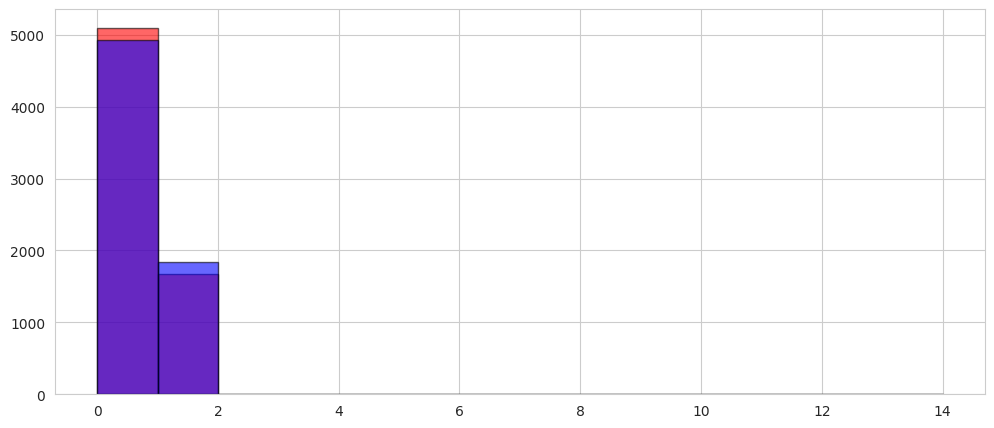

In [ ]:
# ============================================================
# DEFINITION B: pnl_percent > 0
# ============================================================
# First: confirm pnl_percent exists in df after merge.
# If column name differs, find the correct one with df.columns.

print(f'pnl_percent present: {"pnl_percent" in df.columns}')
print(f'NaN count: {df["pnl_percent"].isna().sum() if "pnl_percent" in df.columns else "N/A"}')

# 1. Calculate metrics cleanly
Mae = df['mae_percent'].abs()
Mfe = df['mfe_percent'].abs()
df['target_b'] =((Mfe / (Mfe + Mae)) * Mfe)*2.5

# # # 2. Complete target_B assignment
# # df['target_B'] = (df['pnl_percent'] > 0).astype(int)

# # # 3. Print the Class Balance Breakdown for target_B
# # print('Definition B: pnl_percent > 0')
# # balance = df['target_B'].value_counts(normalize=True) * 100
# # for val, pct in balance.items():
# #     print(f"   Target {val} (Win/Loss): {pct:.2f}%")
# # print("-" * 40)

# # 4. Corrected Plotting Code
# plt.figure(figsize=(10, 6))

# # Dynamic binning based on your data's actual max score
# max_score = df['target_b'].max()
# bin_edges = np.arange(0, 15, 1) # Smaller bins for percentages

plt.hist(df['classification_target_1'].dropna(), alpha=0.6, bins=bin_edges, edgecolor='black', color='r')

plt.hist(df['classification_target_2'].dropna(), alpha=0.6, bins=bin_edges, edgecolor='black', color='b')

# # # Dynamic Ticks based on data scale
# # plt.xticks(np.arange(0, max(1.0, max_score), 0.05), rotation=45)
# # plt.xlim(0, max(0.5, df['classification_target_2'].quantile(0.99))) # Zoom to 95th percentile

# plt.title('Distribution of Custom Trade Quality Score')
# plt.xlabel('Score')
# plt.ylabel('Frequency')
# plt.tight_layout()
# plt.show()

# Strip away the outer df[...] wrapper
df['classification_target_2'] = (df['target_b'] > 2.5).astype(int)
matching_rows = len(df[(df['classification_target_2'] == 1) & (df['classification_target_1'] == 1)])
print(f"Number of overlapping high-quality trades: {matching_rows}")

In [ ]:
df[['classification_target_2', 'T3_Assumption_Penalty']]

,classification_target_2,T3_Assumption_Penalty
0,0,5.20
1,0,1.64
2,0,10.00
3,1,8.37
4,0,5.75
...,...,...
6768,0,3.62
6769,1,7.50
6770,0,7.88
6771,0,3.52


In [ ]:
# ============================================================
# DEFINITION C: MFE / MAE R:R filter
# ============================================================
MFE_THRESHOLD = None  # TODO: e.g. 2.0
MAE_THRESHOLD = None  # TODO: e.g. -1.0  (negative: it's a drawdown)

def MFEvMAE(dataset):
  # get the 2 column, but the way my dataset is i have max move up and max move down and so i have to figure out mae
  df['max_move_down_pct'], df['max_move_up_pct'] , df['mfe_percent']

print(f'Definition C: mfe >= {MFE_THRESHOLD} AND mae >= {MAE_THRESHOLD}')
print('  TODO: fill in class balance')


In [ ]:
# ============================================================
# CLASS BALANCE COMPARISON TABLE
# ============================================================
# TODO: Fill in actual numbers after computing each definition above.

balance_summary = pd.DataFrame({
    'Definition':    ['A: target_special >= thresh', 'B: pnl_percent > 0', 'C: MFE/MAE R:R'],
    'N_positive':    [None, None, None],   # TODO
    'N_negative':    [None, None, None],   # TODO
    'Pct_positive':  [None, None, None],   # TODO
    'LONG_pct_pos':  [None, None, None],   # TODO
    'SHORT_pct_pos': [None, None, None],   # TODO
})
print(balance_summary.to_string(index=False))

# TODO: Write in a comment which definition you are choosing and WHY.
# Hint: think about FP cost (entering a bad trade) vs FN cost (missing a good one).
# For a live trading system with real capital, which error is more expensive?


In [ ]:
# ============================================================
# LOCK IN YOUR TARGET + COMPUTE BAYES PRIOR
# ============================================================
# TODO: Set df['target'] = df['target_X']  (replace X with your chosen definition)

TARGET_BINARY = 'target'

prior_pos = df[TARGET_BINARY].mean()
print(f'Prior P(good signal) = {prior_pos:.3f}  ({prior_pos*100:.1f}%)')
print(f'Prior P(bad signal)  = {1-prior_pos:.3f}  ({(1-prior_pos)*100:.1f}%)')
print()
print(f'Dumb baseline accuracy (always predict majority): {max(prior_pos, 1-prior_pos):.3f}')
print('Your model must beat this to be worth anything.')

# TODO: Conditional probability exercise
# Calculate P(good signal | ADX > 25)  vs  P(good signal | ADX <= 25)
# Does high ADX make a good signal more or less likely on your data?
# p_good_adx_high = df[df['adx_ltf'] > 25][TARGET_BINARY].mean()
# p_good_adx_low  = df[df['adx_ltf'] <= 25][TARGET_BINARY].mean()
print('P(good | ADX > 25):  TODO')
print('P(good | ADX <= 25): TODO')


## Section 6 — Logistic Regression Mathematics (Tuesday)

Before writing any model code, understand what is happening under the hood.

### The core pipeline
1. Compute linear combination: `z = w₀ + w₁x₁ + ... + wₙxₙ`
2. Apply sigmoid: `σ(z) = 1 / (1 + e⁻ᶣ)` → probability between 0 and 1
3. Decision: if `σ(z) >= threshold` → predict 1 (good signal), else 0

### Log-loss
Loss = `−[y log(p) + (1−y) log(1−p)]`

### Regularisation
| | L1 (Lasso) | L2 (Ridge) |
|--|--|--|
| Penalty | λΣ|wᵢ| | λΣwᵢ² |
| Effect | Pushes weights to **exactly zero** | Shrinks all weights |
| Use when | Many features are irrelevant | All features contribute |
| sklearn | `penalty='l1'`, `solver='liblinear'` | `penalty='l2'` (default) |

`C = 1/λ` — **higher C = less regularisation = more complex model**

> **Deliverable for Tuesday:** 2 pages of handwritten derivations. Work through the gradient of log-loss with respect to one weight, then the L2 penalty term. Do this before running any code.


In [ ]:
# ============================================================
# SIGMOID FUNCTION
# ============================================================
z = np.linspace(-10, 10, 300)

# TODO: sigma = 1 / (1 + np.exp(-z))
sigma = None

fig, ax = plt.subplots(figsize=(10, 5))
# TODO: ax.plot(z, sigma)
# Add dashed horizontals at y=0, 0.5, 1
# Add dashed vertical at x=0
# Annotate the decision boundary point (0, 0.5)
# Title: 'Sigmoid Function - Logistic Regression Output'
plt.tight_layout()
plt.show()

# TODO: Answer in comments:
# 1. sigma(0) = ?
# 2. sigma(10) ~= ?
# 3. sigma(-10) ~= ?
# 4. At what z does the model flip its prediction (default threshold)?


In [ ]:
# ============================================================
# LOG-LOSS: manual implementation + verification
# ============================================================

def log_loss_manual(y_true, y_prob):
    """
    Binary cross-entropy: -mean[y*log(p) + (1-y)*log(1-p)]
    Clip p to avoid log(0).
    """
    # TODO: clip p to (1e-9, 1-1e-9)
    # TODO: compute element-wise loss, return mean
    pass

y_sample = np.array([1, 0, 1, 1, 0])
p_sample  = np.array([0.9, 0.2, 0.7, 0.4, 0.8])

manual = log_loss_manual(y_sample, p_sample)
print(f'Manual log-loss:  {manual}')

# Verify against sklearn:
# from sklearn.metrics import log_loss
# print(f'sklearn log-loss: {log_loss(y_sample, p_sample)}')

# Hand calculation for one sample (y=1, p=0.7):
print(f'Single sample (y=1, p=0.7): loss = {-np.log(0.7):.4f}')
# TODO: In a comment: what happens to the loss as p -> 0 for a true positive?


## Section 7 — Baseline Logistic Regression — LONG Signals (Wednesday)

Train `LogisticRegression(C=1.0)` on your binary target. Time-based 80/20 split, scale on train only.

> **Trading interpretation of the confusion matrix:**
> - **FP** (model says good, trade is bad) → bad trade entered, capital at risk
> - **FN** (model says bad, trade is good) → missed winner, opportunity cost
> - **TP** → correctly identified good entry
> - **TN** → correctly avoided a loser

> For a live system with limited capital, FP is usually more costly than FN. Your threshold tuning in Section 9 should reflect your personal answer to this.


In [ ]:
# ============================================================
# LONG SIGNALS: data prep
# ============================================================
FEATURES = FEATURES_LONG_MI

df_long = df[df['signal_x'] == 'LONG'].copy()
df_long = df_long[['checked_at_utc', 'symbol'] + FEATURES + [TARGET_BINARY]].dropna()

print(f'LONG signals: {len(df_long):,} rows')
print(f'Class balance: {df_long[TARGET_BINARY].mean()*100:.1f}% positive')
print(f'NaN remaining: {df_long.isna().sum().sum()}')


In [ ]:
# ============================================================
# TIME-BASED TRAIN/TEST SPLIT: 80/20 chronological
# ============================================================
long_sorted = df_long.sort_values('checked_at_utc').reset_index(drop=True)
split_idx   = int(len(long_sorted) * 0.8)

train_long = long_sorted.iloc[:split_idx]
test_long  = long_sorted.iloc[split_idx:]

assert train_long['checked_at_utc'].max() <= test_long['checked_at_utc'].min(), 'Time leakage!'

print(f'Train: {len(train_long):,} rows | {train_long["checked_at_utc"].min().date()} to {train_long["checked_at_utc"].max().date()}')
print(f'Test:  {len(test_long):,} rows  | {test_long["checked_at_utc"].min().date()} to {test_long["checked_at_utc"].max().date()}')
print(f'Train balance: {train_long[TARGET_BINARY].mean()*100:.1f}% positive')
print(f'Test  balance: {test_long[TARGET_BINARY].mean()*100:.1f}% positive')


In [ ]:
# ============================================================
# SCALING: fit on train, transform both
# ============================================================
scaler_long = StandardScaler()

X_train_long = train_long[FEATURES].values
y_train_long = train_long[TARGET_BINARY].values
X_test_long  = test_long[FEATURES].values
y_test_long  = test_long[TARGET_BINARY].values

X_train_long_sc = scaler_long.fit_transform(X_train_long)
X_test_long_sc  = scaler_long.transform(X_test_long)

print('Scaling check (first 5 features):')
print(f'  Train mean (~0): {X_train_long_sc.mean(axis=0)[:5].round(3)}')
print(f'  Train std  (~1): {X_train_long_sc.std(axis=0)[:5].round(3)}')
print(f'  Test  mean (!=0): {X_test_long_sc.mean(axis=0)[:5].round(3)}')
# TODO: In a comment - why is the test mean not exactly 0?


In [ ]:
# ============================================================
# TRAIN BASELINE LOGISTIC REGRESSION
# ============================================================
# TODO: Initialise LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs')
# TODO: Fit on X_train_long_sc, y_train_long
# TODO: y_pred_long  = lr_long.predict(X_test_long_sc)
# TODO: y_prob_long  = lr_long.predict_proba(X_test_long_sc)[:, 1]

lr_long = None  # YOUR CODE

# TODO: Compute metrics
acc  = None  # accuracy_score(y_test_long, y_pred_long)
prec = None  # precision_score(...)
rec  = None  # recall_score(...)
f1   = None  # f1_score(...)
auc  = None  # roc_auc_score(y_test_long, y_prob_long)

print('=' * 50)
print('LOGISTIC REGRESSION BASELINE - LONG signals')
print('=' * 50)
print(f'  Accuracy:  {acc}')
print(f'  Precision: {prec}  <- of signals flagged good, how many were?')
print(f'  Recall:    {rec}   <- of all good signals, how many caught?')
print(f'  F1-Score:  {f1}')
print(f'  ROC-AUC:   {auc}')
print()
dumb = max(y_test_long.mean(), 1-y_test_long.mean())
print(f'  Dumb baseline accuracy: {dumb:.4f}')
print(f'  Beating it? {"YES" if acc and acc > dumb else "TODO"}')


In [ ]:
# ============================================================
# CONFUSION MATRIX
# ============================================================
cm   = confusion_matrix(y_test_long, y_pred_long)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bad (0)', 'Good (1)'])

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix - Logistic Regression, LONG')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN = {tn:,}  correctly avoided bad trades')
print(f'FP = {fp:,}  bad trades entered wrongly  <- COSTLY')
print(f'FN = {fn:,}  good trades missed           <- opportunity cost')
print(f'TP = {tp:,}  good trades correctly caught')
print()
print(f'FP Rate: {fp/(fp+tn)*100:.1f}%')
print(f'FN Rate: {fn/(fn+tp)*100:.1f}%')
# TODO: Comment - which error is more costly for your strategy?


In [ ]:
# ============================================================
# ROC CURVE
# ============================================================
fpr, tpr, _ = roc_curve(y_test_long, y_prob_long)

plt.figure(figsize=(8, 6))
# TODO: Plot ROC curve: plt.plot(fpr, tpr, label=f'Logistic Reg (AUC={auc:.3f})')
# Add diagonal dashed baseline: plt.plot([0,1],[0,1],'k--')
# Labels: xlabel='False Positive Rate', ylabel='True Positive Rate'
# Title: 'ROC Curve - LONG signals'
plt.tight_layout()
plt.show()

print(f'AUC: {auc}')
# TODO: What does this AUC value mean in trading terms?
# Week 1 best Test R2 was ~0.47 on specific assets. AUC measures something different.
# In 1-2 sentences: what does AUC tell you that R2 did not?


## Section 8 — SHORT Signals Baseline

Repeat the full pipeline for SHORT signals using `FEATURES_SHORT_MI`. Week 1 showed SHORT crossovers had notably better linear regression performance on Target 3 (negative variance phenomenon: test R² > train R² on ETH, BTC, DOGE). Check whether logistic regression mirrors this asymmetry.


In [ ]:
# ============================================================
# SHORT SIGNALS: full pipeline
# ============================================================
# TODO: Filter df to SHORT signals using FEATURES_SHORT_MI
# TODO: Time-based 80/20 split (same structure)
# TODO: NEW scaler fitted on SHORT train only (never reuse long scaler)
# TODO: Train LogisticRegression(C=1.0, max_iter=1000)
# TODO: Evaluate: accuracy, precision, recall, f1, auc
# TODO: Confusion matrix

FEATURES_S = FEATURES_SHORT_MI

# --- your pipeline below ---


# Fill in after running:
acc_s, prec_s, rec_s, f1_s, auc_s = None, None, None, None, None

print('--- LONG vs SHORT Comparison ---')
comp = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
    'LONG':  [acc,   prec,   rec,   f1,   auc],
    'SHORT': [acc_s, prec_s, rec_s, f1_s, auc_s],
})
print(comp.to_string(index=False))
# TODO: Does SHORT outperform LONG as the linear regression story suggested?


## Section 9 — Regularisation + Threshold Tuning (Thursday)

Sweep `C = [0.01, 0.1, 1, 10, 100]` for both L1 and L2. Then use the Precision-Recall curve to find an operating threshold that reflects your actual trading cost structure.


In [ ]:
# ============================================================
# REGULARISATION SWEEP
# ============================================================
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]
reg_results = []

for C in C_values:
    for penalty, solver in [('l2', 'lbfgs'), ('l1', 'liblinear')]:
        # TODO: Train LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=1000)
        # TODO: Predict on X_test_long_sc
        # TODO: Compute accuracy, precision, recall, f1, auc
        reg_results.append({
            'C': C, 'penalty': penalty,
            'accuracy':  None, 'precision': None,
            'recall':    None, 'f1':        None,
            'auc':       None
        })

reg_df = pd.DataFrame(reg_results)
print(reg_df.to_string(index=False))


In [ ]:
# ============================================================
# REGULARISATION CURVE: AUC and F1 vs C
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, metric in enumerate(['auc', 'f1']):
    ax = axes[i]
    for penalty in ['l1', 'l2']:
        sub = reg_df[reg_df['penalty'] == penalty].sort_values('C')
        # TODO: ax.plot(sub['C'], sub[metric], marker='o', label=penalty.upper())
        pass
    ax.set_xscale('log')
    ax.set_xlabel('C (1 / regularisation strength)')
    ax.set_ylabel(metric.upper())
    ax.set_title(f'{metric.upper()} vs C - LONG signals')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# TODO: In a comment:
# - C value where L2 peaks
# - C value where L1 peaks
# - Does very high C (weak regularisation) show overfitting?
# - Does L1 or L2 generalise better on this data?

BEST_C = None  # TODO: set from sweep results
print(f'Chosen C: {BEST_C}')


In [ ]:
# ============================================================
# PRECISION-RECALL CURVE
# ============================================================
# TODO: Retrain with BEST_C, get y_prob_best on test set
# lr_best = LogisticRegression(C=BEST_C, max_iter=1000)
# lr_best.fit(X_train_long_sc, y_train_long)
# y_prob_best = lr_best.predict_proba(X_test_long_sc)[:, 1]

prec_curve, rec_curve, thresholds_pr = precision_recall_curve(y_test_long, y_prob_long)
ap = average_precision_score(y_test_long, y_prob_long)

plt.figure(figsize=(10, 6))
# TODO: plt.plot(thresholds_pr, prec_curve[:-1], label='Precision')
# TODO: plt.plot(thresholds_pr, rec_curve[:-1],  label='Recall')
# Add vertical line at default threshold 0.5
# Title: 'Precision-Recall vs Threshold - LONG signals'
# xlabel: 'Decision Threshold'
plt.tight_layout()
plt.show()

print(f'Average Precision (AP): {ap:.4f}')
print()
# TODO: Find threshold where precision first exceeds 0.65:
# idx = np.argmax(prec_curve[:-1] >= 0.65)
# chosen_threshold = thresholds_pr[idx]
# print(f'Conservative threshold (prec>=0.65): {chosen_threshold:.3f}, recall={rec_curve[idx]:.3f}')
print('Chosen threshold: TODO - justify in a comment')


In [ ]:
# ============================================================
# CLASS IMBALANCE: balanced weights vs quality sample weights
# ============================================================
# Option A: automatic balanced weighting
# lr_bal = LogisticRegression(C=BEST_C, class_weight='balanced', max_iter=1000)
# lr_bal.fit(X_train_long_sc, y_train_long)

# Option B: quality scores as sample weights
# lr_qw = LogisticRegression(C=BEST_C, max_iter=1000)
# lr_qw.fit(X_train_long_sc, y_train_long,
#           sample_weight=train_long['target_special'].values)

# TODO: Evaluate both. Print comparison:
print('Unweighted:          prec=TODO  rec=TODO  f1=TODO  auc=TODO')
print('Balanced weights:    prec=TODO  rec=TODO  f1=TODO  auc=TODO')
print('Quality sw weights:  prec=TODO  rec=TODO  f1=TODO  auc=TODO')
print()
print('TODO: Which approach gives best precision without collapsing recall?')
print('TODO: Which will you carry forward into Week 3?')


## Section 10 — Odds Ratios + Feature Interpretation (Friday)

In logistic regression, the **odds ratio** for feature `i` is `exp(wᵢ)`:
- OR > 1 → feature increases probability of a good signal
- OR < 1 → feature decreases probability of a good signal
- OR ≈ 1 → feature has little effect

This differs from linear regression coefficients — these measure *multiplicative* changes in odds, not additive changes in output.


In [ ]:
# ============================================================
# ODDS RATIOS
# ============================================================
# TODO: Extract coefficients from lr_best.coef_[0]
# TODO: odds_ratios = np.exp(coefficients)
# TODO: Build DataFrame: feature, coefficient, odds_ratio
# TODO: Sort by abs(coefficient), show top 10

coef_df = pd.DataFrame({
    'feature':     FEATURES_LONG_MI,
    'coefficient': None,  # TODO: lr_best.coef_[0]
    'odds_ratio':  None,  # TODO: np.exp(...)
})
# coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)

print('Top 10 features by odds ratio magnitude:')
print('TODO: print coef_df.head(10)')


In [ ]:
# ============================================================
# ODDS RATIO BAR CHART
# ============================================================
# TODO: top_features = coef_df.head(10)
# Horizontal bar chart of odds_ratio values
# Colour bars: green if OR > 1, red if OR < 1
# Add vertical line at x=1.0 (neutral - no effect)
# Title: 'Odds Ratios - Logistic Regression, LONG signals'
# xlabel: 'Odds Ratio (exp(coefficient))'

# TODO: Answer in comments:
# 1. Is htf_4h_bias OR > 1 or < 1? What does that mean for LONG entry?
# 2. Do volume features (volume_ratio, crossover_volume_ratio) increase or decrease odds?
# 3. Do these odds ratios agree with Week 1 linear regression coefficient directions?
#    If they disagree on a feature, what might explain it?
print('TODO: generate bar chart')


## Section 11 — Walk-Forward CV Preview

Full walk-forward framework arrives in Week 3. This section builds intuition for *why* it is necessary.

**Why k-fold is wrong for time series:**
Standard k-fold randomly shuffles the data before splitting. For a time series, this means fold N might train on data from January and test on December, while also training on December data in another fold. The model sees future information during training — a form of look-ahead leakage. In live trading, you never have future data. Your CV score will be artificially optimistic.

`TimeSeriesSplit` always keeps training data **before** test data chronologically.


In [ ]:
# ============================================================
# WALK-FORWARD CV PREVIEW
# ============================================================
tscv = TimeSeriesSplit(n_splits=5)

# Use your best model from the regularisation sweep
# TODO: lr_cv = LogisticRegression(C=BEST_C, max_iter=1000)
# TODO: cv_scores = cross_val_score(lr_cv, X_train_long_sc, y_train_long,
#                                   cv=tscv, scoring='roc_auc')

cv_scores = [None] * 5  # TODO: replace with actual scores

print('Walk-forward CV AUC (5 folds, LONG train set):')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s}')
print(f'  Mean: TODO +/- TODO')
print()
print(f'Held-out test AUC (final 20%): {auc}')
print()
# TODO: Is the CV mean close to the held-out test AUC?
# If not, which direction is the gap? What does it tell you about the model?
# Why would random k-fold give an artificially inflated AUC here?


## Section 12 — Per-Symbol Performance

The model was trained on all 5 coins pooled. Check whether this hides wide per-coin variation.


In [ ]:
# ============================================================
# PER-SYMBOL EVALUATION
# ============================================================
symbols = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT', 'DOGEUSDT']
sym_results = []

for sym in symbols:
    mask = test_long['symbol'] == sym
    X_sym = X_test_long_sc[mask.values]
    y_sym = y_test_long[mask.values]

    if len(y_sym) < 10 or y_sym.sum() == 0 or (1 - y_sym).sum() == 0:
        print(f'{sym}: skipped (too few samples or single class)')
        continue

    # TODO: predict on X_sym using lr_best
    # TODO: compute acc, prec, rec, f1, auc for this symbol

    sym_results.append({
        'symbol':      sym,
        'n_test':      len(y_sym),
        'pct_pos':     round(y_sym.mean(), 3),
        'accuracy':    None,  # TODO
        'precision':   None,  # TODO
        'recall':      None,  # TODO
        'f1':          None,  # TODO
        'auc':         None,  # TODO
    })

sym_df = pd.DataFrame(sym_results)
print('Per-Symbol Performance (LONG):')
print(sym_df.to_string(index=False))
print()
print('TODO: Which symbol does the model perform best on?')
print('TODO: Does this match the Week 1 per-symbol linear regression story?')


## Section 13 — Week 2 Honest Baseline Record

Fill this in with actual numbers before closing. Every future model must beat these figures.

In [ ]:
# ============================================================
# WEEK 2 HONEST BASELINE RECORD
# ============================================================
print("""
=================================================================
           WEEK 2 BASELINE - Logistic Regression
=================================================================
  TARGET DEFINITION
    Definition chosen:        ___  (A / B / C)
    Threshold / condition:    ___
    LONG class balance:       ___% positive
    SHORT class balance:      ___% positive

  BEST HYPERPARAMETERS
    Best C:                   ___
    Penalty:                  L1 / L2
    Operating threshold:      ___  (0.5 default if not tuned)
    Class weighting strategy: ___

  LONG SIGNALS (MI 15-feature set)
    Accuracy:   ___    Precision: ___
    Recall:     ___    F1-Score:  ___
    ROC-AUC:    ___

  SHORT SIGNALS (MI 15-feature set)
    Accuracy:   ___    Precision: ___
    Recall:     ___    F1-Score:  ___
    ROC-AUC:    ___

  PER-SYMBOL (LONG)
    Best  AUC: ___ on ___
    Worst AUC: ___ on ___

  VS WEEK 1 LINEAR REGRESSION
    Week 1 best Test R2:      ___ on ___ (target ___)
    Week 2 best ROC-AUC:      ___
    Is classification better frame? YES / NO

  TOP 3 FEATURES BY ODDS RATIO (LONG)
    1. ___ (OR = ___)
    2. ___ (OR = ___)
    3. ___ (OR = ___)

  HONEST VERDICT
    Good enough to trade live?        YES / NO
    Main limitation:                  ___
    What Week 3 must address:         ___
=================================================================
""")


## 📝 Week 2 Assignments

Complete before Week 3. The Week 3 review will check these.

---

**Assignment 1 — Target sensitivity**
Run the full LONG pipeline for all three binary definitions (A, B, C). Build a 3-row table: precision, recall, F1, AUC per definition. Which definition produces the most useful model? Justify in two sentences.

---

**Assignment 2 — Full feature set vs MI set**
Retrain using `FEATURES_ALL` (33 features) instead of `FEATURES_LONG_MI` (15). Does more features help or hurt? Compare AUC and F1. Is there more overfitting? This confirms whether your Week 1 MI pruning was actually worth it.

---

**Assignment 3 — Threshold analysis table**
For your best LONG model, compute precision, recall, F1 at thresholds `[0.3, 0.4, 0.5, 0.6, 0.7]`. Print a 5-row table. Mark the threshold you would use in production and state why.

---

**Assignment 4 — SHORT odds ratios**
Train the SHORT model with your best C. Print odds ratios for the top 10 SHORT features. Which features flip direction (OR > 1 on LONG, OR < 1 on SHORT)? What does that imply?

---

**Assignment 5 — Walk-forward reflection**
In 3–4 sentences: explain why k-fold CV would be wrong for this dataset, and what `TimeSeriesSplit` does differently. Use a concrete example referencing your actual train/test date range.
